              ts_code   open   high    low  close  change      volume  \
trade_date                                                              
2020-08-06  000002.SZ  27.38  27.63  26.99  27.38    0.03   827242.10   
2020-08-07  000002.SZ  27.19  27.36  26.90  27.03   -0.35   664062.85   
2020-08-10  000002.SZ  27.08  27.94  27.05  27.81    0.78  1052840.04   
2020-08-11  000002.SZ  27.92  28.44  27.81  27.88    0.07  1038365.84   
2020-08-12  000002.SZ  27.89  28.71  27.80  28.71    0.83  1249774.08   
...               ...    ...    ...    ...    ...     ...         ...   
2020-12-25  000002.SZ  27.95  28.22  27.60  28.10    0.16   425877.23   
2020-12-28  000002.SZ  28.18  28.65  27.86  28.42    0.32   583680.64   
2020-12-29  000002.SZ  28.56  28.86  28.32  28.52    0.10   539042.91   
2020-12-30  000002.SZ  28.47  28.65  28.22  28.38   -0.14   499718.54   
2020-12-31  000002.SZ  28.29  28.80  28.24  28.70    0.32   651991.11   

                diff       dea      macd  ...  res

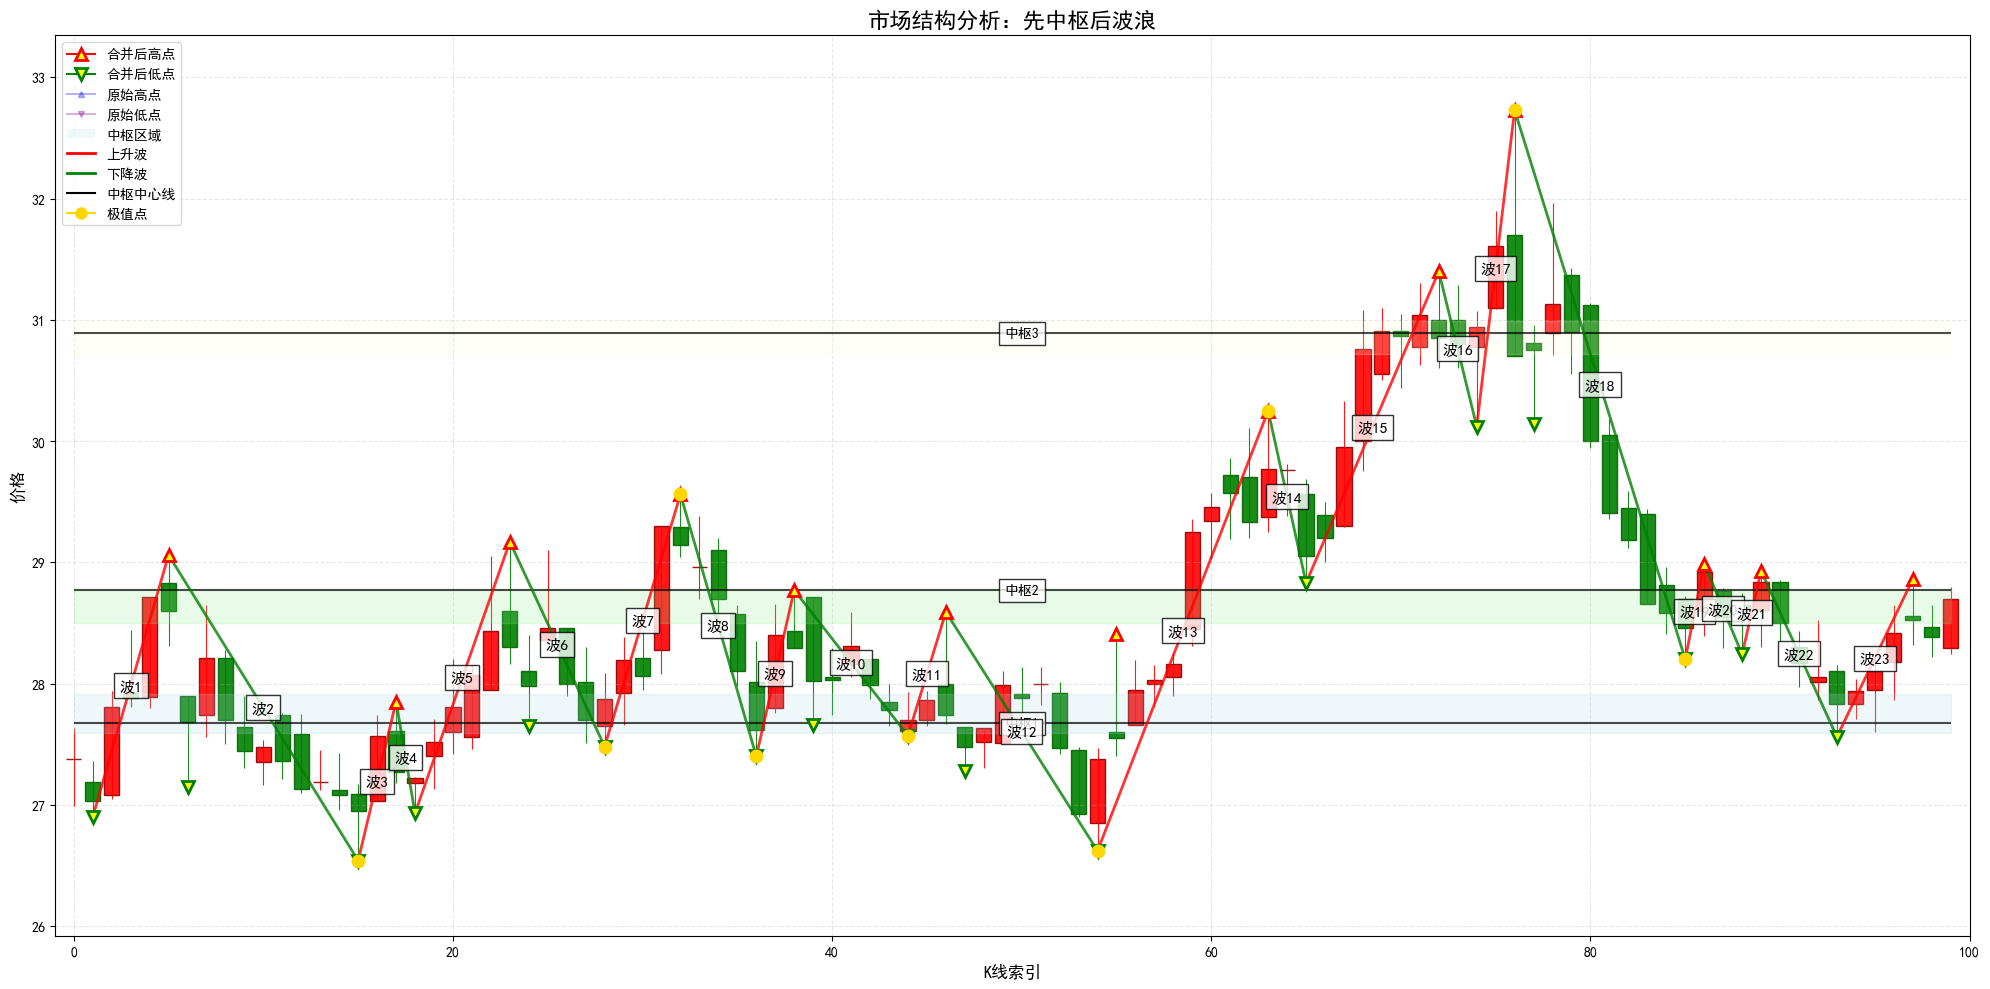

In [6]:
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import argrelextrema
import pandas as pd
import matplotlib
from sklearn.cluster import KMeans
import os
from pathlib import Path


def detect_high_low_points(df, window=2):
    """
    可靠检测高点和低点极点
    """
    if 'high' not in df.columns or 'low' not in df.columns:
        raise ValueError("DataFrame必须包含'high'和'low'列")
    
    high_prices = df['high'].values
    low_prices = df['low'].values
    
    # 检测高点（局部最大值）
    high_indices = argrelextrema(high_prices, np.greater, order=window)[0]
    # 检测低点（局部最小值）
    low_indices = argrelextrema(low_prices, np.less, order=window)[0]
    
    # 检查窗口的第一个和最后一个点是否是极值
    if len(df) > 0:
        if len(high_prices) > 0 and high_prices[0] >= max(high_prices[:min(3, len(high_prices))]):
            if 0 not in high_indices:
                high_indices = np.insert(high_indices, 0, 0)
        
        if len(low_prices) > 0 and low_prices[0] <= min(low_prices[:min(3, len(low_prices))]):
            if 0 not in low_indices:
                low_indices = np.insert(low_indices, 0, 0)
        
        if len(high_prices) > 0 and high_prices[-1] >= max(high_prices[-min(3, len(high_prices)):]):
            if len(high_prices)-1 not in high_indices:
                high_indices = np.append(high_indices, len(high_prices)-1)
        
        if len(low_prices) > 0 and low_prices[-1] <= min(low_prices[-min(3, len(low_prices)):]):
            if len(low_prices)-1 not in low_indices:
                low_indices = np.append(low_indices, len(low_prices)-1)
    
    # 创建标记列
    df = df.copy()
    df['is_high'] = False
    df['is_low'] = False
    df['is_extreme_high'] = False
    df['is_extreme_low'] = False
    
    # 标记高点和低点
    df.iloc[high_indices, df.columns.get_loc('is_high')] = True
    df.iloc[low_indices, df.columns.get_loc('is_low')] = True
    
    # 检测极高点
    if len(high_indices) >= 3:
        for i in range(1, len(high_indices) - 1):
            prev_idx = high_indices[i-1]
            current_idx = high_indices[i]
            next_idx = high_indices[i+1]
            
            current_high = high_prices[current_idx]
            prev_high = high_prices[prev_idx]
            next_high = high_prices[next_idx]
            
            if current_high > prev_high and current_high > next_high:
                df.iloc[current_idx, df.columns.get_loc('is_extreme_high')] = True
    
    # 检测极低点
    if len(low_indices) >= 3:
        for i in range(1, len(low_indices) - 1):
            prev_idx = low_indices[i-1]
            current_idx = low_indices[i]
            next_idx = low_indices[i+1]
            
            current_low = low_prices[current_idx]
            prev_low = low_prices[prev_idx]
            next_low = low_prices[next_idx]
            
            if current_low < prev_low and current_low < next_low:
                df.iloc[current_idx, df.columns.get_loc('is_extreme_low')] = True
    
    return df

def mark_extremes_in_merged_points(merged_points, df):
    """
    在 merge_nearby_points 输出的 points 列表中：
    - 找出连续的 high 或 low 段；
    - 若段内无极值，则将最值点标记为极值（通过修改 df）。
    
    Parameters:
        merged_points: list of (idx, type, price)
        df: 原始 DataFrame（需包含 is_extreme_high/is_extreme_low 列）
    
    Returns:
        无（直接修改 df）
    """
    if len(merged_points) == 0:
        return

    # 确保 df 有极值列
    if 'is_extreme_high' not in df.columns:
        df['is_extreme_high'] = False
    if 'is_extreme_low' not in df.columns:
        df['is_extreme_low'] = False

    i = 0
    n = len(merged_points)
    
    while i < n:
        curr_type = merged_points[i][1]
        segment = []
        j = i
        
        # 收集连续同类型点
        while j < n and merged_points[j][1] == curr_type:
            segment.append(merged_points[j])
            j += 1
        
        # 检查这段是否已有极值
        has_extreme = False
        for idx, pt_type, price in segment:
            if pt_type == 'high':
                if df.iloc[idx]['is_extreme_high']:
                    has_extreme = True
                    break
            else:
                if df.iloc[idx]['is_extreme_low']:
                    has_extreme = True
                    break
        
        # 如果没有极值，且长度 >= 2，标记最值
        if not has_extreme and len(segment) >= 2:
            if curr_type == 'high':
                # 找最高价
                max_pt = max(segment, key=lambda x: x[2])
                df.iloc[max_pt[0], df.columns.get_loc('is_extreme_high')] = True
            else:  # low
                min_pt = min(segment, key=lambda x: x[2])
                df.iloc[min_pt[0], df.columns.get_loc('is_extreme_low')] = True
        
        i = j  # 跳到下一段

def merge_nearby_points(points, centers, price_range, merge_threshold=0.05):
    """
    合并中枢附近的高低点
    """
    if not points or not centers:
        return points
    
    merge_distance = price_range * merge_threshold
    
    merged_points = []
    i = 0
    
    while i < len(points):
        current_point = points[i]
        current_idx, current_type, current_price = current_point
        
        near_center = False
        for center in centers:
            if abs(current_price - center) <= merge_distance:
                near_center = True
                break
        
        if near_center:
            group = [current_point]
            j = i + 1
            
            while j < len(points):
                next_point = points[j]
                next_idx, next_type, next_price = next_point
                
                next_near_center = False
                for center in centers:
                    if abs(next_price - center) <= merge_distance:
                        next_near_center = True
                        break
                
                if next_near_center and next_type == current_type:
                    group.append(next_point)
                    j += 1
                else:
                    break
            
            if len(group) > 1:
                merged_points.append(group[0])
                merged_points.append(group[-1])
            else:
                merged_points.append(current_point)
            
            i = j
        else:
            merged_points.append(current_point)
            i += 1
    
    return merged_points

def simple_connect_points(points, df_with_high_low):
    """
    波浪连接：从当前点出发，向后找到下一个反向类型段，
    在该段中：优先连第一个极值点，否则连最后一个点。
    连接后，从目标点继续，中间全部跳过。
    """
    if len(points) < 2:
        return []

    waves = []
    i = 0
    n = len(points)

    while i < n:
        curr_idx, curr_type, curr_price = points[i]
        target_type = 'low' if curr_type == 'high' else 'high'

        # Step 1: 找到从 i+1 开始的第一个 target_type 段（连续的）
        j = i + 1
        # 跳过非 target_type 的点（理论上不会出现，但保险）
        while j < n and points[j][1] != target_type:
            j += 1
        
        if j >= n:
            break  # 没有目标类型了

        # Step 2: 收集整个连续的 target_type 段
        segment_start = j
        while j < n and points[j][1] == target_type:
            j += 1
        segment_end = j  # segment is [segment_start, segment_end)

        target_segment = points[segment_start:segment_end]

        # Step 3: 在 segment 中找第一个极值点
        target_point = None
        for pt in target_segment:
            pt_idx, pt_type, pt_price = pt
            is_extreme = False
            if pt_type == 'high':
                is_extreme = df_with_high_low.iloc[pt_idx]['is_extreme_high']
            else:
                is_extreme = df_with_high_low.iloc[pt_idx]['is_extreme_low']
            
            if is_extreme:
                target_point = pt
                break
        
        # 如果没极值，取 segment 最后一个点
        if target_point is None:
            target_point = target_segment[-1]

        # Step 4: 创建波浪
        if curr_type == 'low':
            wave = {
                'start_idx': curr_idx,
                'end_idx': target_point[0],
                'start_type': 'low',
                'end_type': 'high',
                'direction': 'up',
                'start_price': curr_price,
                'end_price': target_point[2],
                'height': target_point[2] - curr_price
            }
        else:
            wave = {
                'start_idx': curr_idx,
                'end_idx': target_point[0],
                'start_type': 'high',
                'end_type': 'low',
                'direction': 'down',
                'start_price': curr_price,
                'end_price': target_point[2],
                'height': curr_price - target_point[2]
            }
        waves.append(wave)

        # Step 5: 找到 target_point 在 points 中的索引，作为下一次起点
        next_i = segment_start
        while next_i < segment_end and points[next_i] != target_point:
            next_i += 1
        
        if next_i >= segment_end:
            next_i = segment_end - 1  # fallback to last

        i = next_i  # 从目标点继续

    return waves

def identify_waves_from_points(points, df_with_high_low):
    """
    从高低点序列识别波浪
    """
    if len(points) < 2:
        return []
    
    # 使用简单连接方法
    waves = simple_connect_points(points, df_with_high_low)
    
    # 为波浪编号
    for i, wave in enumerate(waves):
        wave['wave_number'] = i + 1
    
    return waves

class KLineCenterAnalyzer:
    def __init__(self, window=5, shadow_ratio=0.7, min_zone_separation=0.02, 
                 max_zone_width_ratio=0.1, entity_size_threshold=0.05):
        self.window = window
        self.shadow_ratio = shadow_ratio
        self.min_zone_separation = min_zone_separation
        self.max_zone_width_ratio = max_zone_width_ratio
        self.entity_size_threshold = entity_size_threshold
    
    def is_bullish(self, open_price, close_price):
        """判断是否为阳线"""
        return close_price >= open_price
    
    def calculate_shadow_ratio(self, open_price, high_price, low_price, close_price):
        """计算影线比例"""
        body_size = abs(close_price - open_price)
        upper_shadow = high_price - max(open_price, close_price)
        lower_shadow = min(open_price, close_price) - low_price
        
        if body_size == 0:
            return upper_shadow, lower_shadow, 0
        
        return upper_shadow, lower_shadow, max(upper_shadow, lower_shadow) / body_size
    
    def find_reversal_points(self, df):
        """寻找K线反转点"""
        reversal_points = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        for i in range(1, len(opens)-1):
            # 检查颜色反转
            prev_bullish = self.is_bullish(opens[i-1], closes[i-1])
            curr_bullish = self.is_bullish(opens[i], closes[i])
            next_bullish = self.is_bullish(opens[i+1], closes[i+1])
            
            # 颜色反转点
            if (prev_bullish != curr_bullish) or (curr_bullish != next_bullish):
                reversal_points.append(('color_reversal', i, closes[i]))
            
            # 检查影线反转
            _, _, ratio_curr = self.calculate_shadow_ratio(
                opens[i], highs[i], lows[i], closes[i])
            
            # 影线比例超过阈值，可能是反转点
            if ratio_curr > self.shadow_ratio:
                upper_shadow, lower_shadow, _ = self.calculate_shadow_ratio(
                    opens[i], highs[i], lows[i], closes[i])
                
                if upper_shadow > lower_shadow:
                    reversal_points.append(('upper_shadow', i, highs[i]))
                else:
                    reversal_points.append(('lower_shadow', i, lows[i]))
        
        return reversal_points
    
    def find_volume_price_points(self, df):
        """寻找成交量极值点对应的K线价格"""
        volumes = df['volume'].values
        closes = df['close'].values
        
        # 寻找成交量局部高点
        volume_high_idx = argrelextrema(volumes, np.greater, order=self.window)[0]
        
        volume_points = []
        for idx in volume_high_idx:
            volume_points.append(('volume_price', idx, closes[idx]))
        
        return volume_points
    
    def cluster_prices(self, points, n_clusters=6):
        """对价格点进行聚类，返回聚类中心"""
        if not points:
            return []
            
        prices = np.array([point[2] for point in points]).reshape(-1, 1)
        
        if len(prices) <= n_clusters:
            return sorted([p[0] for p in prices])
        
        kmeans = KMeans(n_clusters=min(n_clusters, len(prices)), random_state=0).fit(prices)
        centers = sorted([center[0] for center in kmeans.cluster_centers_])
        return centers
    
    def find_centers(self, df):
        """找出中枢水平线"""
        reversal_points = self.find_reversal_points(df)
        volume_points = self.find_volume_price_points(df)
        
        all_points = reversal_points + volume_points
        
        if not all_points:
            return [], [], []
        
        center_lines = self.cluster_prices(all_points, 3)
        
        return center_lines, reversal_points, volume_points
    
    def calculate_center_zones(self, df, center_lines):
        """计算中枢区域，确保不重叠"""
        center_zones = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        price_range = np.max(highs) - np.min(lows)
        min_separation = price_range * self.min_zone_separation
        max_zone_width = price_range * self.max_zone_width_ratio
        
        entity_sizes = np.abs(closes - opens)
        entity_size_threshold = np.percentile(entity_sizes, 95)
        
        for center_line in center_lines:
            crossing_k_lines = []
            for i in range(len(df)):
                if lows[i] <= center_line <= highs[i]:
                    entity_high = max(opens[i], closes[i])
                    entity_low = min(opens[i], closes[i])
                    entity_size = entity_high - entity_low
                    
                    if entity_size <= entity_size_threshold:
                        crossing_k_lines.append((entity_high, entity_low))
            
            if crossing_k_lines:
                entity_highs = [h for h, l in crossing_k_lines]
                entity_lows = [l for h, l in crossing_k_lines]
                
                zone_high = np.mean(entity_highs)
                zone_low = np.mean(entity_lows)
                
                min_zone_height = price_range * 0.005
                if zone_high - zone_low < min_zone_height:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + min_zone_height / 2
                    zone_low = mid_point - min_zone_height / 2
                
                if zone_high - zone_low > max_zone_width:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + max_zone_width / 2
                    zone_low = mid_point - max_zone_width / 2
                
                overlap_found = False
                for i, (existing_center, existing_low, existing_high, existing_count) in enumerate(center_zones):
                    if not (zone_high < existing_low or zone_low > existing_high):
                        # 发现重叠，合并区域
                        merged_low = min(zone_low, existing_low)
                        merged_high = max(zone_high, existing_high)
                        
                        if merged_high - merged_low > max_zone_width:
                            mid_point = (merged_low + merged_high) / 2
                            merged_low = mid_point - max_zone_width / 2
                            merged_high = mid_point + max_zone_width / 2
                        
                        merged_center = (center_line + existing_center) / 2
                        merged_count = len(crossing_k_lines) + existing_count
                        
                        center_zones[i] = (merged_center, merged_low, merged_high, merged_count)
                        overlap_found = True
                        break
                
                if not overlap_found:
                    center_zones.append((center_line, zone_low, zone_high, len(crossing_k_lines)))
        
        # 确保区域之间有最小分离距离，防止重叠
        center_zones.sort(key=lambda x: x[0])
        
        non_overlapping_zones = []
        for zone in center_zones:
            center_line, zone_low, zone_high, count = zone
            
            if not non_overlapping_zones:
                non_overlapping_zones.append(zone)
                continue
                
            # 检查是否与已有区域重叠
            overlaps = False
            for existing_zone in non_overlapping_zones:
                existing_center, existing_low, existing_high, existing_count = existing_zone
                
                if not (zone_high < existing_low or zone_low > existing_high):
                    # 有重叠，跳过这个区域
                    overlaps = True
                    break
            
            if not overlaps:
                non_overlapping_zones.append(zone)
        
        # 按中心线排序
        non_overlapping_zones.sort(key=lambda x: x[0])
        
        return non_overlapping_zones




def visualize_market_structure(df, start_date=None, end_date=None):    
    """可视化市场结构：中枢、波浪运动"""
    # 重置索引为连续整数索引
    df = df.reset_index(drop=True)
    
    # 设置中文字体
    matplotlib.rcParams['font.sans-serif'] = ['SimHei']
    matplotlib.rcParams['axes.unicode_minus'] = False
    
    # 确定数据范围
    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        df = df[df.index >= start_date]
    if end_date is not None:
        end_date = pd.to_datetime(end_date)
        df = df[df.index <= end_date]
    
    if len(df) == 0:
        print("所选日期范围内无数据")
        return None
    
    # 1. 先找中枢
    analyzer = KLineCenterAnalyzer()
    center_lines, reversal_points, volume_points = analyzer.find_centers(df)
    center_zones = analyzer.calculate_center_zones(df, center_lines)
    
    # 2. 再找高低点
    df_with_high_low = detect_high_low_points(df)
    
    # 获取所有高低点
    high_points = [(idx, 'high', df.iloc[idx]['high']) for idx in df_with_high_low[df_with_high_low['is_high']].index]
    low_points = [(idx, 'low', df.iloc[idx]['low']) for idx in df_with_high_low[df_with_high_low['is_low']].index]
    
    # 合并高低点并按索引排序
    all_points = sorted(high_points + low_points, key=lambda x: x[0])
    
    # 3. 合并中枢附近的高低点
    price_range = df['high'].max() - df['low'].min()
    merged_points = merge_nearby_points(all_points, center_lines, price_range)
    # 新增：在合并后的点序列中补全极值
    mark_extremes_in_merged_points(merged_points, df_with_high_low)
    # 4. 从合并后的点识别波浪
    waves = identify_waves_from_points(merged_points, df_with_high_low)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # 设置坐标轴范围
    price_padding = price_range * 0.1
    y_min = df['low'].min() - price_padding
    y_max = df['high'].max() + price_padding
    ax.set_ylim(y_min, y_max)
    
    # 绘制K线图 - 使用标准红绿色
    x = np.arange(len(df))
    opens = df['open'].values
    highs = df['high'].values
    lows = df['low'].values
    closes = df['close'].values
    
    # 分离阳线和阴线
    up_indices = closes >= opens
    down_indices = closes < opens
    
    # 阳线 - 红色
    if np.any(up_indices):
        up_x = x[up_indices]
        up_highs = highs[up_indices]
        up_lows = lows[up_indices]
        up_opens = opens[up_indices]
        up_closes = closes[up_indices]
        
        ax.vlines(up_x, up_lows, up_highs, color='red', linewidth=0.8, alpha=0.9)
        ax.bar(up_x, up_closes - up_opens, 0.8, up_opens, 
               color='red', edgecolor='darkred', alpha=0.9)
    
    # 阴线 - 绿色
    if np.any(down_indices):
        down_x = x[down_indices]
        down_highs = highs[down_indices]
        down_lows = lows[down_indices]
        down_opens = opens[down_indices]
        down_closes = closes[down_indices]
        
        ax.vlines(down_x, down_lows, down_highs, color='green', linewidth=0.8, alpha=0.9)
        ax.bar(down_x, down_closes - down_opens, 0.8, down_opens, 
               color='green', edgecolor='darkgreen', alpha=0.9)


    high_points_pre = df_with_high_low[df_with_high_low['is_high']]
    low_points_pre = df_with_high_low[df_with_high_low['is_low']]
    
    ax.plot(high_points_pre.index, high_points_pre['high'], '^', color='blue', markersize=4, 
             alpha=0.3, zorder=5)
    ax.plot(low_points_pre.index, low_points_pre['low'], 'v', color='purple', markersize=4, 
             alpha=0.3, zorder=5)
    
    # 标记合并后的高低点
    for idx, point_type, price in merged_points:
        if point_type == 'high':
            ax.plot(idx, price, '^', color='red', markersize=8, 
                    markeredgewidth=2, markerfacecolor='yellow', zorder=6)
        else:
            ax.plot(idx, price, 'v', color='green', markersize=8, 
                    markeredgewidth=2, markerfacecolor='yellow', zorder=6)
    
    # 绘制中枢区域 - 水平延长铺满，确保不重叠
    colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lightcyan']
    for i, (center_line, zone_low, zone_high, k_line_count) in enumerate(center_zones):
        # 中枢区域从图表最左边到最右边
        start_idx = 0
        end_idx = len(df) - 1
        
        color_idx = i % len(colors)
        rect = patches.Rectangle(
            (start_idx, zone_low),
            end_idx - start_idx,
            zone_high - zone_low,
            alpha=0.2, color=colors[color_idx], zorder=2
        )
        ax.add_patch(rect)
        
        # 绘制中枢中心线 - 水平延长铺满
        ax.hlines(center_line, start_idx, end_idx, 
                 colors='black', linestyles='-', linewidth=1.5, alpha=0.7, zorder=3)
        
        # 标注中枢
        ax.text(
            len(df) / 2,  # 放在图表中间
            center_line,
            f'中枢{i+1}',
            fontsize=10, ha='center', va='center', 
            bbox=dict(facecolor='white', alpha=0.8), zorder=5
        )
    
    # 绘制波浪
    for wave in waves:
        start_idx = wave['start_idx']
        end_idx = wave['end_idx']
        start_price = wave['start_price']
        end_price = wave['end_price']
        direction = wave['direction']
        wave_number = wave['wave_number']
        
        # 暂时将所有波浪都标记为基本波浪，后续再分类
        color = 'red' if direction == 'up' else 'green'
        linestyle = '-'
        linewidth = 2
        wave_text = f'波{wave_number}'
        
        # 绘制波浪线
        ax.plot([start_idx, end_idx], [start_price, end_price], 
                color=color, linestyle=linestyle, linewidth=linewidth, alpha=0.8, zorder=4)
        
        # 标记波浪信息
        mid_x = (start_idx + end_idx) / 2
        mid_y = (start_price + end_price) / 2
        
        ax.text(mid_x, mid_y, wave_text, 
                fontsize=11, ha='center', va='center', 
                bbox=dict(facecolor='white', alpha=0.8), zorder=5)
    
    # 标记极值点
    extreme_high_points = df_with_high_low[df_with_high_low['is_extreme_high']]
    extreme_low_points = df_with_high_low[df_with_high_low['is_extreme_low']]
    
    ax.plot(extreme_high_points.index, extreme_high_points['high'], 'o', 
            color='gold', markersize=8, markeredgewidth=2, zorder=7)
    ax.plot(extreme_low_points.index, extreme_low_points['low'], 'o', 
            color='gold', markersize=8, markeredgewidth=2, zorder=7)
    
    # 设置图表格式
    ax.set_title('市场结构分析：先中枢后波浪', fontsize=16, fontweight='bold')
    ax.set_ylabel('价格', fontsize=12)
    ax.set_xlabel('K线索引', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.set_xlim(-1, len(df))
    
    # 创建图例
    legend_elements = [
        Line2D([0], [0], marker='^', color='red', markerfacecolor='yellow', 
               markersize=8, markeredgewidth=2, label='合并后高点'),
        Line2D([0], [0], marker='v', color='green', markerfacecolor='yellow', 
               markersize=8, markeredgewidth=2, label='合并后低点'),
        Line2D([0], [0], marker='^', color='blue', markerfacecolor='blue', 
               markersize=4, label='原始高点', alpha=0.3),
        Line2D([0], [0], marker='v', color='purple', markerfacecolor='purple', 
               markersize=4, label='原始低点', alpha=0.3),
        patches.Patch(facecolor='lightblue', alpha=0.2, label='中枢区域'),
        Line2D([0], [0], color='red', linestyle='-', lw=2, label='上升波'),
        Line2D([0], [0], color='green', linestyle='-', lw=2, label='下降波'),
        Line2D([0], [0], color='black', linestyle='-', lw=1.5, label='中枢中心线'),
        Line2D([0], [0], marker='o', color='gold', markerfacecolor='gold', 
               markersize=8, label='极值点')
    ]
    
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('market_structure_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        'center_zones': center_zones,
        'waves': waves,
        'merged_points': merged_points,
        'all_points': all_points
    }

# 使用示例
if __name__ == "__main__":
    # 这里应该是您的数据加载代码
    ts_code = "000002.SZ"
    analysis_dir = 'E:/stock/csv_version/analysis_results'
    csv_path = f"{analysis_dir}/{ts_code}_analysis.csv"
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'], nrows=100)
    print(df)
    
    # 运行分析
    result = visualize_market_structure(df)